<a href="https://colab.research.google.com/github/UTD2026/Mixed_Dataset_Testing_STA/blob/main/SBAR_Offline_GoNoGo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# S-BAR offline go/no-go: is there a compute-Pareto win for router-based TTL?

Decides whether to commit runway to **S-BAR** (a budget router that sends each unit to
base / light / full adaptation) *before* any budget-arm GPU training. Per your teammate's
review: **selection-quality simulation on existing artifacts first.**

Question: does a **deployable** signal (base uncertainty, or TLM's input-perplexity `q_ce`)
recover most of full-TLM's adaptation gain at a **fraction of the budget**, beating random
and beating `top_qce` (TLM's own selection)? Accuracy is expected to be near-capped — the
win lives on the **compute axis** (recover the gain cheaper), which is the winnable framing.

Self-contained: reuses cached `saves_beat_tlm` if present; regenerates features / base preds /
`fulldata` adapter / base-confidence if missing. Cheap (MAXNEW=12, big batch).

In [1]:
# ---- repo / runtime knobs ----
REPO_URL = "https://github.com/UTD2026/rishabh-tlm.git"
WORK = "/content/v2_dynamic_ce"                       # change if not on Colab
LOCAL_REPO_ZIP = "/content/rishabh-tlm-ab-routing-2026-07-02.zip"  # clone fallback
GITHUB_TOKEN_ENV = "GITHUB_TOKEN"                     # optional, for private clone
MODEL = "Qwen/Qwen3.5-0.8B"
DATASETS = ["logiqa", "medicine", "geography"]        # geography = honest negative case
N_BY_DATASET = {"logiqa": 1000, "medicine": 1000, "geography": 225}
print({"work": WORK, "model": MODEL, "datasets": DATASETS})


{'work': '/content/v2_dynamic_ce', 'model': 'Qwen/Qwen3.5-0.8B', 'datasets': ['logiqa', 'medicine', 'geography']}


## Environment setup

Written for a CUDA GPU box (Colab/H200/Ada). Skip the install cell if your image already has these packages.

In [2]:
import os, sys, subprocess, json, textwrap, shutil, pathlib, time
from pathlib import Path

Path(WORK).mkdir(parents=True, exist_ok=True)
os.chdir(WORK)
print("cwd:", os.getcwd())

cwd: /content/v2_dynamic_ce


In [3]:
# Fresh Colab runtime install / compatibility setup.
# Qwen3.5 needs newer Transformers support. Generation is patched to use Transformers,
# because Colab/vLLM CUDA wheels can mismatch (e.g. libcudart.so.13 missing).
# Runtime > Restart runtime after this cell if pip asks or if imports still show stale versions.
import os, sys, subprocess, shutil

INSTALL_DEPS = True
USE_QWEN35_COMPAT_INSTALL = True  # keep True for MODEL="Qwen/Qwen3.5-0.8B"
INSTALL_VLLM = False  # keep False on Colab unless you have a known-compatible vLLM/CUDA wheel

if INSTALL_DEPS:
    def pip_install(*args):
        cmd = [sys.executable, "-m", "pip", "install", "-U", *args]
        print("RUN:", " ".join(cmd))
        subprocess.check_call(cmd)

    pip_install("pip")
    pip_install("peft", "accelerate", "scipy", "sympy", "ninja", "pandas", "matplotlib", "torchvision", "pillow", "huggingface_hub")

    if USE_QWEN35_COMPAT_INSTALL and "Qwen3.5" in MODEL:
        # HF model card recommends latest Transformers for Qwen3.5.
        pip_install("transformers[serving] @ git+https://github.com/huggingface/transformers.git@main")
    else:
        pip_install("transformers")

    if INSTALL_VLLM:
        # Optional only. The notebook patches ab_generate.py to use Transformers by default.
        # Use this only if your runtime has a vLLM wheel matching its CUDA/PyTorch stack.
        try:
            cmd = [sys.executable, "-m", "pip", "install", "-U", "vllm", "--extra-index-url", "https://wheels.vllm.ai/nightly"]
            print("RUN:", " ".join(cmd))
            subprocess.check_call(cmd)
        except Exception as e:
            print("Nightly vLLM install failed, falling back to normal vLLM:", repr(e))
            pip_install("vllm")

    # Qwen3.5 GDN Triton JIT expects ninja on PATH in this codebase's README.
    ninja = shutil.which("ninja")
    if ninja:
        print("ninja:", ninja)
    else:
        print("WARNING: ninja still not found on PATH")

import torch, transformers
print("torch:", torch.__version__)
print("cuda available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("gpu:", torch.cuda.get_device_name(0))
print("transformers:", transformers.__version__)
if INSTALL_VLLM:
    try:
        import vllm
        print("vllm:", getattr(vllm, "__version__", "unknown"))
    except Exception as e:
        print("vllm import warning:", repr(e))
else:
    print("vllm skipped; ab_generate.py will use Transformers fallback")


RUN: /usr/bin/python3 -m pip install -U pip
RUN: /usr/bin/python3 -m pip install -U peft accelerate scipy sympy ninja pandas matplotlib torchvision pillow huggingface_hub
RUN: /usr/bin/python3 -m pip install -U transformers[serving] @ git+https://github.com/huggingface/transformers.git@main
ninja: /usr/local/bin/ninja
torch: 2.12.1+cu130
cuda available: True
gpu: NVIDIA RTX PRO 6000 Blackwell Server Edition
transformers: 5.14.0.dev0
vllm skipped; ab_generate.py will use Transformers fallback


### Fix CUDA / optional-dependency mismatches (torchaudio, torchvision, torchao)

Current Colab images carry several optional extensions that are *installed but version- or
CUDA-mismatched*, and the git-main `transformers` / `peft` treat "present but incompatible" as
a hard error instead of "absent, skip it":

- `torchaudio` is built for CUDA 12.8 against a CUDA-13 PyTorch. `transformers` imports it while
  loading **text** model modules (`peft` -> `BloomPreTrainedModel` -> `loss_utils` -> `loss_rnnt`),
  so its CUDA check crashes the whole pipeline.
- `torchao` ships as 0.10.0, but `peft`'s LoRA dispatcher requires > 0.16.0 and *raises* from
  `is_torchao_available()` during `get_peft_model(...)` even though this LoRA config uses plain
  `Linear` layers and never needs torchao.
- `torchvision` can mismatch CUDA the same way as torchaudio.

None of these are used by this text-only pipeline (no audio, no vision, no quantization), so we
remove them. Once each is absent, the corresponding `is_*_available()` guard returns `False` and
the code skips it cleanly. The cell then forces the exact import + LoRA path the subprocesses use,
so any remaining mismatch surfaces here instead of deep inside a stage.

In [4]:
import sys, subprocess

def _pip(*args):
    print("RUN: pip", *args)
    subprocess.check_call([sys.executable, "-m", "pip", *args])

# Remove optional extensions that are installed-but-incompatible (unused by this pipeline).
for pkg in ["torchaudio", "torchvision", "torchao"]:
    try:
        _pip("uninstall", "-y", pkg)
    except Exception as e:
        print(f"(uninstall {pkg} skipped: {e!r})")

# Drop any half-loaded modules so the verification imports are clean.
for m in list(sys.modules):
    if m.startswith(("torchaudio", "torchvision", "torchao", "transformers", "peft")):
        del sys.modules[m]

import torch
print("torch:", torch.__version__, "| cuda build:", torch.version.cuda, "| cuda avail:", torch.cuda.is_available())

# Force the exact eager chain the subprocesses trigger: text-model import + a LoRA injection.
from transformers import AutoModelForCausalLM, AutoTokenizer, BloomPreTrainedModel  # noqa: F401
from peft import LoraConfig, TaskType, get_peft_model  # noqa: F401
import torch.nn as nn
_probe = nn.Linear(8, 8)
class _Tiny(nn.Module):
    def __init__(self):
        super().__init__()
        self.proj = nn.Linear(8, 8)
    def forward(self, x):
        return self.proj(x)
_ = get_peft_model(_Tiny(), LoraConfig(target_modules=["proj"], r=2))  # exercises the LoRA dispatcher
print("transformers + peft + LoRA dispatch OK (no torchaudio/torchao crash)")


RUN: pip uninstall -y torchaudio
RUN: pip uninstall -y torchvision
RUN: pip uninstall -y torchao
torch: 2.12.1+cu130 | cuda build: 13.0 | cuda avail: True
transformers + peft + LoRA dispatch OK (no torchaudio/torchao crash)


In [5]:
# Clone / update repo, with token + zip fallback
import os, subprocess, shutil, zipfile, glob
from pathlib import Path

repo_dir = Path(WORK) / "rishabh-tlm"


def _run_capture(cmd, cwd=None):
    """Run a shell command and return CompletedProcess while preserving stdout/stderr."""
    return subprocess.run(
        [str(x) for x in cmd],
        cwd=cwd,
        text=True,
        stdout=subprocess.PIPE,
        stderr=subprocess.PIPE,
    )


def _clone_url_with_optional_token(url: str) -> str:
    token = os.environ.get(GITHUB_TOKEN_ENV, "").strip()
    if token and url.startswith("https://github.com/"):
        # Do not print this URL; it contains a secret.
        return url.replace("https://", f"https://{token}@", 1)
    return url


def _unzip_repo(zip_path: Path, dest: Path):
    zip_path = Path(zip_path).expanduser().resolve()
    if not zip_path.exists():
        raise FileNotFoundError(f"Repo zip does not exist: {zip_path}")

    print(f"Using repo zip fallback: {zip_path}")
    tmp = dest.parent / "_repo_zip_extract_tmp"
    if tmp.exists():
        shutil.rmtree(tmp)
    tmp.mkdir(parents=True, exist_ok=True)

    with zipfile.ZipFile(zip_path, "r") as zf:
        zf.extractall(tmp)

    # Common cases: zip contains a single top-level folder, or contains repo files directly.
    candidates = [p for p in tmp.iterdir() if p.is_dir()]
    selected = None
    for cand in candidates:
        if (cand / "cuda_ttl" / "ab_routing").exists() or (cand / ".git").exists():
            selected = cand
            break
    if selected is None:
        if (tmp / "cuda_ttl" / "ab_routing").exists():
            selected = tmp
        elif len(candidates) == 1:
            selected = candidates[0]
        else:
            raise RuntimeError(
                "Could not identify repo root inside zip. "
                f"Top-level entries: {[p.name for p in tmp.iterdir()][:20]}"
            )

    if dest.exists():
        shutil.rmtree(dest)
    if selected == tmp:
        shutil.copytree(tmp, dest, dirs_exist_ok=True)
        shutil.rmtree(tmp, ignore_errors=True)
    else:
        shutil.move(str(selected), str(dest))
        shutil.rmtree(tmp, ignore_errors=True)

    if not (dest / "cuda_ttl" / "ab_routing").exists():
        raise RuntimeError(f"Unzipped repo does not contain cuda_ttl/ab_routing: {dest}")


def _find_repo_zip():
    """Find an already-present repo zip in the locations Colab commonly uses."""
    explicit = Path(LOCAL_REPO_ZIP).expanduser()
    search_roots = [
        explicit.parent,
        Path(WORK),
        Path.cwd(),
        Path("/content"),
        Path("/mnt/data"),  # works in ChatGPT sandbox, harmless in Colab if absent
    ]

    candidates = []
    if explicit.exists():
        candidates.append(explicit)
    for root in search_roots:
        try:
            if root.exists():
                candidates.extend(Path(x) for x in glob.glob(str(root / "rishabh-tlm*.zip")))
        except Exception:
            pass

    # de-dupe while preserving order
    out = []
    seen = set()
    for c in candidates:
        try:
            resolved = c.resolve()
        except Exception:
            continue
        if c.exists() and resolved not in seen:
            out.append(c)
            seen.add(resolved)
    return out[0] if out else None


def _upload_repo_zip_colab():
    """Upload a zip in Colab and return the actual path it was written to.

    Colab saves uploads into the current working directory, not necessarily /content.
    The previous notebook assumed /content/<name>, which caused FileNotFoundError.
    This version verifies the path and falls back to writing uploaded bytes manually.
    """
    from google.colab import files

    print("No local repo zip found. Upload rishabh-tlm-ab-routing-2026-07-02.zip now.")
    uploaded = files.upload()
    zip_names = [name for name in uploaded if name.lower().endswith(".zip")]
    if not zip_names:
        raise RuntimeError("No .zip file uploaded.")

    name = zip_names[0]
    candidates = [
        Path.cwd() / name,
        Path(WORK) / name,
        Path("/content") / name,
        Path(name),
    ]
    for candidate in candidates:
        if candidate.exists():
            print(f"Uploaded zip found at: {candidate.resolve()}")
            return candidate.resolve()

    # Defensive fallback: Colab returned bytes, so write them somewhere we control.
    fallback = Path(WORK) / name
    fallback.parent.mkdir(parents=True, exist_ok=True)
    fallback.write_bytes(uploaded[name])
    print(f"Uploaded zip bytes written to: {fallback.resolve()}")
    return fallback.resolve()


if repo_dir.exists():
    print("repo already exists:", repo_dir)
    # keep this non-destructive; uncomment if you explicitly want latest remote
    # subprocess.check_call(["git", "-C", str(repo_dir), "pull"])
else:
    clone_url = _clone_url_with_optional_token(REPO_URL)
    print("Cloning repo...")
    cp = _run_capture(["git", "clone", clone_url, str(repo_dir)])
    if cp.returncode != 0:
        print("git clone failed.")
        if cp.stdout.strip():
            print("--- git stdout ---")
            print(cp.stdout[-4000:])
        if cp.stderr.strip():
            print("--- git stderr ---")
            # Redact token if present.
            safe_stderr = cp.stderr
            token = os.environ.get(GITHUB_TOKEN_ENV, "").strip()
            if token:
                safe_stderr = safe_stderr.replace(token, "<GITHUB_TOKEN>")
            print(safe_stderr[-4000:])

        zip_path = _find_repo_zip()
        if zip_path is None:
            try:
                zip_path = _upload_repo_zip_colab()
            except Exception as upload_e:
                raise RuntimeError(
                    "Could not clone the repo and no repo zip fallback was available.\n\n"
                    "Most likely causes:\n"
                    "1) The GitHub repo is private and Colab has no auth. Set os.environ['GITHUB_TOKEN'] first.\n"
                    "2) The URL/branch is wrong or unavailable.\n"
                    "3) Colab/network blocked GitHub.\n\n"
                    f"Original git error:\n{cp.stderr[-2000:]}"
                ) from upload_e

        _unzip_repo(Path(zip_path), repo_dir)

os.chdir(repo_dir)
print("repo:", repo_dir)
try:
    head = subprocess.check_output(["git", "rev-parse", "--short", "HEAD"], text=True, stderr=subprocess.DEVNULL).strip()
    print("git head:", head)
except Exception:
    print("git head unavailable: repo loaded from zip or non-git folder")

print("ab_routing files:")
for p in sorted((repo_dir / "cuda_ttl" / "ab_routing").glob("ab_*.py")):
    print(" -", p.relative_to(repo_dir))


Cloning repo...
git clone failed.
--- git stderr ---
Cloning into '/content/v2_dynamic_ce/rishabh-tlm'...
fatal: could not read Username for 'https://github.com': No such device or address

No local repo zip found. Upload rishabh-tlm-ab-routing-2026-07-02.zip now.


Saving rishabh-tlm-ab-routing-2026-07-02.zip to rishabh-tlm-ab-routing-2026-07-02.zip
Uploaded zip found at: /content/v2_dynamic_ce/rishabh-tlm-ab-routing-2026-07-02.zip
Using repo zip fallback: /content/v2_dynamic_ce/rishabh-tlm-ab-routing-2026-07-02.zip
repo: /content/v2_dynamic_ce/rishabh-tlm
git head unavailable: repo loaded from zip or non-git folder
ab_routing files:
 - cuda_ttl/ab_routing/ab_build_pool.py
 - cuda_ttl/ab_routing/ab_generate.py
 - cuda_ttl/ab_routing/ab_route_eval.py
 - cuda_ttl/ab_routing/ab_train_ttl.py


In [6]:
# Runtime patch: make model loading more robust for Qwen3.5 and add clear preflight checks.
# This is non-destructive to the repo ZIP; it only edits the working copy inside WORK.
from pathlib import Path
import subprocess, sys, os

if not Path("cuda_ttl/ab_routing/ab_build_pool.py").exists():
    raise FileNotFoundError("Run the repo setup cell first; cuda_ttl/ab_routing/ab_build_pool.py not found.")

# 1) ab_build_pool.py originally hard-coded AutoModelForCausalLM.
# For Qwen3.5, use the checkpoint-declared architecture when Transformers knows it;
# otherwise fall back to AutoModelForCausalLM.
p = Path("cuda_ttl/ab_routing/ab_build_pool.py")
s = p.read_text()
s = s.replace(
    '    from transformers import AutoModelForCausalLM, AutoTokenizer\n'
    '    from peft import LoraConfig, TaskType, get_peft_model\n'
    '    tokenizer = AutoTokenizer.from_pretrained(args.model)\n'
    '    model = AutoModelForCausalLM.from_pretrained(args.model, torch_dtype=torch.bfloat16,\n'
    '                                                 device_map="cuda")\n',
    '    import transformers\n'
    '    from transformers import AutoConfig, AutoModelForCausalLM, AutoTokenizer\n'
    '    from peft import LoraConfig, TaskType, get_peft_model\n'
    '    tokenizer = AutoTokenizer.from_pretrained(args.model, trust_remote_code=True)\n'
    '    cfg = AutoConfig.from_pretrained(args.model, trust_remote_code=True)\n'
    '    arch = (getattr(cfg, "architectures", None) or [""])[0]\n'
    '    model_cls = getattr(transformers, arch, None) or AutoModelForCausalLM\n'
    '    print(f"loading with {model_cls.__name__}")\n'
    '    model = model_cls.from_pretrained(args.model, torch_dtype=torch.bfloat16,\n'
    '                                      device_map="cuda", trust_remote_code=True)\n'
)
p.write_text(s)

# 2) Add trust_remote_code to train loader too, same idea.
p = Path("cuda_ttl/ab_routing/ab_train_ttl.py")
s = p.read_text()
s = s.replace('    tokenizer = AutoTokenizer.from_pretrained(args.model)\n', '    tokenizer = AutoTokenizer.from_pretrained(args.model, trust_remote_code=True)\n')
s = s.replace('    cfg = AutoConfig.from_pretrained(args.model)\n', '    cfg = AutoConfig.from_pretrained(args.model, trust_remote_code=True)\n')
s = s.replace('    model = model_cls.from_pretrained(args.model, torch_dtype=torch.bfloat16,\n                                      device_map="cuda")\n',
              '    model = model_cls.from_pretrained(args.model, torch_dtype=torch.bfloat16,\n                                      device_map="cuda", trust_remote_code=True)\n')
p.write_text(s)

# 3) Hard preflight before burning time.
import torch, transformers
from transformers import AutoConfig, AutoTokenizer
print("MODEL =", MODEL)
print("torch =", torch.__version__)
print("transformers =", transformers.__version__)
print("cuda =", torch.cuda.is_available())
if not torch.cuda.is_available():
    raise RuntimeError("CUDA is not available. In Colab: Runtime -> Change runtime type -> GPU.")
print("gpu =", torch.cuda.get_device_name(0))
try:
    tok = AutoTokenizer.from_pretrained(MODEL, trust_remote_code=True)
    cfg = AutoConfig.from_pretrained(MODEL, trust_remote_code=True)
    print("model_type =", getattr(cfg, "model_type", None))
    print("architectures =", getattr(cfg, "architectures", None))
    print("tokenizer ok; chat_template =", bool(getattr(tok, "chat_template", None)))
except Exception as e:
    raise RuntimeError(
        "Model/tokenizer preflight failed. If MODEL is Qwen/Qwen3.5-0.8B, rerun the install cell, "
        "restart runtime if needed, or set MODEL='Qwen/Qwen2.5-0.5B-Instruct' for a text-only smoke test."
    ) from e

print("patched scripts ok")
for file in ["ab_build_pool.py", "ab_train_ttl.py"]:
    subprocess.check_call([sys.executable, "-m", "py_compile", str(Path("cuda_ttl/ab_routing") / file)])
    print("py_compile ok:", file)


MODEL = Qwen/Qwen3.5-0.8B
torch = 2.12.1+cu130
transformers = 5.14.0.dev0
cuda = True
gpu = NVIDIA RTX PRO 6000 Blackwell Server Edition


config.json:   0%|          | 0.00/2.91k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/16.7k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/6.72M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/3.35M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/12.8M [00:00<?, ?B/s]

chat_template.jinja:   0%|          | 0.00/7.75k [00:00<?, ?B/s]

model_type = qwen3_5
architectures = ['Qwen3_5ForConditionalGeneration']
tokenizer ok; chat_template = True
patched scripts ok
py_compile ok: ab_build_pool.py
py_compile ok: ab_train_ttl.py


In [7]:
# Data paths expected by cuda_ttl/ab_routing/run_ab.sh, but we call scripts directly.
DATA_FILES = {
    "logiqa": "data/AdaptEval/logiqa_random_5k.json",
    "medicine": "data/AdaptEval/medicine_mcqa_random_5k.json",
    "geography": "data/AdaptEval/geography_mmlu.json",
    "gsm8k": "data/AdaptEval/gsm8k_random_5k.json",
}

missing = [p for ds, p in DATA_FILES.items() if ds in DATASETS and not Path(p).exists()]
if missing:
    raise FileNotFoundError(
        "Missing dataset files: " + ", ".join(missing) +
        "\nThe uploaded repo snapshot included these under data/AdaptEval/. If your clone does not, copy them there before running."
    )

for ds in DATASETS:
    print(ds, "->", DATA_FILES[ds], "exists", Path(DATA_FILES[ds]).exists())

logiqa -> data/AdaptEval/logiqa_random_5k.json exists True
medicine -> data/AdaptEval/medicine_mcqa_random_5k.json exists True
geography -> data/AdaptEval/geography_mmlu.json exists True


In [8]:
# ---- resolve paths (cwd is the repo root after the clone cell) ----
from pathlib import Path
SCRIPTS = Path("cuda_ttl/ab_routing").resolve()
REPO_DIR = Path.cwd()
ARTIFACT_ROOT = Path(WORK) / "saves_dynamic_v2ce"   # reuse prior pools/base preds if present
ANCHOR_ROOT = Path(WORK) / "saves_anchor"           # this experiment's outputs
ANCHOR_ROOT.mkdir(parents=True, exist_ok=True)
assert SCRIPTS.exists(), "run the clone cell first"
print("repo:", REPO_DIR, "| scripts:", SCRIPTS)


repo: /content/v2_dynamic_ce/rishabh-tlm | scripts: /content/v2_dynamic_ce/rishabh-tlm/cuda_ttl/ab_routing


## Write the anchored trainer

Writes `ab_train_ttl_anchored.py` (vanilla objective at `--anchor-lambda 0` plus the anchor flags) and the HF `ab_generate.py`. Both are py-compiled here so a syntax problem surfaces before any GPU time.

In [9]:
# ---- write the anchored trainer and the HF generation script into the repo ----
import subprocess, sys
from pathlib import Path

trainer_src = "#!/usr/bin/env python\n\"\"\"\nStage 2: TTL LoRA training on the admission-selected pool \u2014 CUDA port of\nmlx_ttl/train_ttl_mlx.py in its --selection-file mode (CE gate bypassed; train ONLY on\nthe selected idxs, weighted). Same recipe: chat-templated (user, assistant=output)\npairs, loss on completion tokens only, LoRA q_proj+v_proj r8 alpha16 dropout0 on all\nlayers, AdamW lr 5e-5, cosine schedule with 10% warmup, 1 epoch, batch 1, seed 42.\n\nSaves the peft adapter AND a merged full model (merge_and_unload) so vLLM generation\ncannot silently no-op the adapter (the vLLM-0.24 LoRA module-naming gotcha).\n\"\"\"\n\nimport argparse\nimport json\nimport math\nimport os\nimport random\nimport time\n\nimport torch\n\n\ndef build_user(rec):\n    if \"instruction\" in rec:\n        instruction = (rec.get(\"instruction\") or \"\").strip()\n        extra = (rec.get(\"input\") or \"\").strip()\n        return instruction + ((\"\\n\" + extra) if extra else \"\")\n    return (rec.get(\"question\") or \"\").strip()\n\n\ndef chat_ids(tokenizer, msgs, add_generation_prompt):\n    # template to STRING then encode (BatchEncoding gotcha \u2014 see ab_build_pool.py)\n    try:\n        text = tokenizer.apply_chat_template(\n            msgs, tokenize=False, add_generation_prompt=add_generation_prompt,\n            enable_thinking=False)\n    except TypeError:\n        text = tokenizer.apply_chat_template(\n            msgs, tokenize=False, add_generation_prompt=add_generation_prompt)\n    return tokenizer.encode(text, add_special_tokens=False)\n\n\ndef main():\n    ap = argparse.ArgumentParser(description=\"TTL LoRA on a selected pool (CUDA)\")\n    ap.add_argument(\"--model\", default=\"Qwen/Qwen3.5-0.8B\")\n    ap.add_argument(\"--data\", required=True)\n    ap.add_argument(\"--selection-file\", required=True)\n    ap.add_argument(\"--output-dir\", required=True)\n    ap.add_argument(\"--merged-dir\", default=None, help=\"default <output-dir>/merged\")\n    ap.add_argument(\"--max-samples\", type=int, default=1000)\n    ap.add_argument(\"--max-seq-length\", type=int, default=2048)\n    ap.add_argument(\"--epochs\", type=float, default=1.0)\n    ap.add_argument(\"--learning-rate\", type=float, default=5e-5)\n    ap.add_argument(\"--warmup-ratio\", type=float, default=0.1)\n    ap.add_argument(\"--lora-rank\", type=int, default=8)\n    ap.add_argument(\"--lora-alpha\", type=int, default=16)\n    ap.add_argument(\"--lora-keys\", default=\"q_proj,v_proj\")\n    ap.add_argument(\"--seed\", type=int, default=42)\n    # --- base-anchor (confidence-weighted KL to frozen base) ---\n    ap.add_argument(\"--anchor-lambda\", type=float, default=0.0,\n                    help=\"strength of the base-anchor term; 0.0 == vanilla TLM\")\n    ap.add_argument(\"--anchor-weight\", default=\"confidence\",\n                    choices=[\"confidence\", \"threshold\", \"uniform\"],\n                    help=\"per-token weight on the anchor: confidence=base gold-prob^gamma, \"\n                         \"threshold=1 where base gold-CE<=tau, uniform=1 everywhere\")\n    ap.add_argument(\"--anchor-direction\", default=\"fwd\", choices=[\"fwd\", \"rev\"],\n                    help=\"fwd=KL(base||adapted) (pull adapted toward base); rev=KL(adapted||base)\")\n    ap.add_argument(\"--anchor-tau\", type=float, default=0.3,\n                    help=\"base gold-token CE threshold for --anchor-weight threshold\")\n    ap.add_argument(\"--anchor-gamma\", type=float, default=1.0,\n                    help=\"sharpening exponent for --anchor-weight confidence\")\n    args = ap.parse_args()\n    merged_dir = args.merged_dir or os.path.join(args.output_dir, \"merged\")\n    os.makedirs(args.output_dir, exist_ok=True)\n\n    torch.manual_seed(args.seed)\n    sel = json.load(open(args.selection_file))\n    weights = {int(e[\"idx\"]): float(e[\"weight\"]) for e in sel[\"selected\"]}\n\n    import transformers\n    from transformers import AutoConfig, AutoModelForCausalLM, AutoTokenizer, get_cosine_schedule_with_warmup\n    from peft import LoraConfig, TaskType, get_peft_model\n    tokenizer = AutoTokenizer.from_pretrained(args.model)\n    # Load via the checkpoint's own architecture class (Qwen3_5ForConditionalGeneration),\n    # NOT AutoModelForCausalLM: the latter returns the text submodel, whose merged\n    # save_pretrained writes a Qwen3_5TextConfig that vLLM refuses to load.\n    cfg = AutoConfig.from_pretrained(args.model)\n    arch = (getattr(cfg, \"architectures\", None) or [\"\"])[0]\n    model_cls = getattr(transformers, arch, None) or AutoModelForCausalLM\n    print(f\"loading with {model_cls.__name__}\")\n    model = model_cls.from_pretrained(args.model, torch_dtype=torch.bfloat16,\n                                      device_map=\"cuda\")\n    model = get_peft_model(model, LoraConfig(\n        task_type=TaskType.CAUSAL_LM, r=args.lora_rank, lora_alpha=args.lora_alpha,\n        lora_dropout=0.0, bias=\"none\",\n        target_modules=[k.strip() for k in args.lora_keys.split(\",\")]))\n    model.print_trainable_parameters()\n    device = next(model.parameters()).device\n\n    records = json.load(open(args.data, encoding=\"utf-8\"))[: args.max_samples]\n    samples = []  # (full_ids, prompt_len, idx)\n    for idx, rec in enumerate(records):\n        if idx not in weights:\n            continue\n        user = build_user(rec)\n        output = str(rec.get(\"output\") if \"output\" in rec else rec.get(\"answers\", \"\") or \"\")\n        if not user:\n            continue\n        prompt_ids = chat_ids(tokenizer, [{\"role\": \"user\", \"content\": user}], True)\n        full_ids = chat_ids(tokenizer, [{\"role\": \"user\", \"content\": user},\n                                        {\"role\": \"assistant\", \"content\": output}], False)\n        full_ids = full_ids[: args.max_seq_length]\n        if len(full_ids) <= len(prompt_ids):\n            continue\n        samples.append((full_ids, len(prompt_ids), idx))\n    print(f\"training on {len(samples)} selected samples\")\n\n    steps_per_epoch = len(samples)\n    total_steps = int(steps_per_epoch * args.epochs)\n    warmup_steps = max(1, int(total_steps * args.warmup_ratio))\n    opt = torch.optim.AdamW((p for p in model.parameters() if p.requires_grad),\n                            lr=args.learning_rate)\n    sched = get_cosine_schedule_with_warmup(opt, warmup_steps, total_steps)\n\n    model.train()\n    step, running, t0 = 0, 0.0, time.perf_counter()\n    for epoch in range(math.ceil(args.epochs)):\n        order = list(range(len(samples)))\n        random.Random(args.seed + epoch).shuffle(order)\n        for j in order:\n            if step >= total_steps:\n                break\n            full_ids, plen, idx = samples[j]\n            x = torch.tensor([full_ids], device=device)\n            logits = model(input_ids=x).logits.float()\n            tgt = x[:, 1:]\n            lp = torch.log_softmax(logits[:, :-1, :], dim=-1)\n            ce = -lp.gather(-1, tgt.unsqueeze(-1)).squeeze(-1)[0]\n            task_loss = ce[plen - 1:].mean() * weights[idx]\n\n            # --- base-anchor: confidence-weighted KL to the frozen base -------------\n            # (base = same model with the LoRA adapter disabled; no second model needed)\n            if args.anchor_lambda > 0.0:\n                with torch.no_grad():\n                    with model.disable_adapter():\n                        base_logits = model(input_ids=x).logits.float()\n                la = lp[:, plen - 1:, :]                                   # adapted logp (grad)\n                lb = torch.log_softmax(base_logits[:, :-1, :], dim=-1)[:, plen - 1:, :].detach()\n                if args.anchor_direction == \"fwd\":                        # KL(base||adapted)\n                    kl = (lb.exp() * (lb - la)).sum(-1)[0]\n                else:                                                     # KL(adapted||base)\n                    pa = la.exp()\n                    kl = (pa * (la - lb)).sum(-1)[0]\n                tgt_comp = tgt[:, plen - 1:][0]\n                base_gold_lp = lb[0].gather(-1, tgt_comp.view(-1, 1)).squeeze(-1)  # base logp on gold\n                if args.anchor_weight == \"confidence\":\n                    w = base_gold_lp.exp().clamp(1e-6, 1.0).pow(args.anchor_gamma)\n                elif args.anchor_weight == \"threshold\":\n                    w = ((-base_gold_lp) <= args.anchor_tau).float()\n                else:\n                    w = torch.ones_like(kl)\n                w = w.detach()\n                anchor_loss = (w * kl).sum() / (w.sum() + 1e-8)\n                loss = task_loss + args.anchor_lambda * anchor_loss\n            else:\n                anchor_loss = None\n                loss = task_loss\n            # -----------------------------------------------------------------------\n            opt.zero_grad(set_to_none=True)\n            loss.backward()\n            opt.step()\n            sched.step()\n            running += loss.item()\n            step += 1\n            if step % 20 == 0:\n                extra = \"\" if anchor_loss is None else f\" | anchor {anchor_loss.item():.4f}\"\n                print(f\"step {step}/{total_steps} | loss {running/20:.4f}{extra} \"\n                      f\"| lr {sched.get_last_lr()[0]:.2e} | {step/(time.perf_counter()-t0):.2f} it/s\",\n                      flush=True)\n                running = 0.0\n        if step >= total_steps:\n            break\n\n    model.save_pretrained(args.output_dir)\n    print(f\"adapter -> {args.output_dir}\")\n    merged = model.merge_and_unload()\n    merged.save_pretrained(merged_dir)\n    tokenizer.save_pretrained(merged_dir)\n    # The composite Qwen3.5 arch makes vLLM look for (video) preprocessor configs that\n    # save_pretrained doesn't write \u2014 copy any missing non-weight files from the source\n    # checkpoint so the merged dir loads exactly like the hub model.\n    import shutil\n    from huggingface_hub import snapshot_download\n    src = args.model if os.path.isdir(args.model) else snapshot_download(\n        args.model, allow_patterns=[\"*.json\", \"*.txt\", \"*.jinja\"])\n    for name in os.listdir(src):\n        if \"safetensors\" in name or not os.path.isfile(os.path.join(src, name)):\n            continue\n        dst = os.path.join(merged_dir, name)\n        if not os.path.exists(dst):\n            shutil.copy(os.path.join(src, name), dst)\n            print(f\"  copied {name} from source checkpoint\")\n    print(f\"merged model -> {merged_dir}\")\n\n\nif __name__ == \"__main__\":\n    main()\n"
gen_src = "#!/usr/bin/env python\n\"\"\"\nStage 3: greedy predictions for an AdaptEval bench.\n\nPatched notebook version: uses Hugging Face Transformers instead of vLLM so Colab\nis not blocked by vLLM/CUDA wheel mismatches such as missing libcudart.so.13.\nOutput rows {idx, question, label, predict} match the original script.\n\"\"\"\n\nimport argparse\nimport json\nimport os\nimport time\n\n\ndef build_user(rec):\n    if \"instruction\" in rec:\n        instruction = (rec.get(\"instruction\") or \"\").strip()\n        extra = (rec.get(\"input\") or \"\").strip()\n        return instruction + ((\"\\n\" + extra) if extra else \"\")\n    return (rec.get(\"question\") or \"\").strip()\n\n\ndef gold_label(rec):\n    if rec.get(\"answer\") not in (None, \"\"):\n        return str(rec[\"answer\"]).strip()\n    val = rec.get(\"output\") if \"output\" in rec else rec.get(\"answers\")\n    return str(val or \"\").strip()\n\n\ndef _load_model_and_tokenizer(model_name_or_path):\n    import torch\n    import transformers\n    from transformers import AutoConfig, AutoModelForCausalLM, AutoTokenizer\n\n    tokenizer = AutoTokenizer.from_pretrained(model_name_or_path, trust_remote_code=True)\n    if tokenizer.pad_token_id is None:\n        tokenizer.pad_token = tokenizer.eos_token\n    tokenizer.padding_side = \"left\"\n\n    cfg = AutoConfig.from_pretrained(model_name_or_path, trust_remote_code=True)\n    arch = (getattr(cfg, \"architectures\", None) or [\"\"])[0]\n    model_cls = getattr(transformers, arch, None) or AutoModelForCausalLM\n    print(f\"loading with {model_cls.__name__}\")\n\n    model = model_cls.from_pretrained(\n        model_name_or_path,\n        torch_dtype=torch.bfloat16 if torch.cuda.is_available() else torch.float32,\n        device_map=\"auto\" if torch.cuda.is_available() else None,\n        trust_remote_code=True,\n    )\n    model.eval()\n    return model, tokenizer\n\n\ndef main():\n    ap = argparse.ArgumentParser(description=\"Transformers greedy predictions for AdaptEval\")\n    ap.add_argument(\"--model\", required=True)\n    ap.add_argument(\"--data\", required=True)\n    ap.add_argument(\"--output\", required=True)\n    ap.add_argument(\"--max-samples\", type=int, default=1000)\n    ap.add_argument(\"--max-new-tokens\", type=int, default=1024)\n    ap.add_argument(\"--gpu-mem\", type=float, default=0.85, help=\"kept for CLI compatibility; ignored\")\n    ap.add_argument(\"--max-model-len\", type=int, default=4096)\n    ap.add_argument(\"--batch-size\", type=int, default=8)\n    args = ap.parse_args()\n\n    records = json.load(open(args.data, encoding=\"utf-8\"))[: args.max_samples]\n\n    model, tokenizer = _load_model_and_tokenizer(args.model)\n\n    def chat(user):\n        msgs = [{\"role\": \"user\", \"content\": user}]\n        try:\n            return tokenizer.apply_chat_template(\n                msgs, tokenize=False, add_generation_prompt=True, enable_thinking=False\n            )\n        except TypeError:\n            return tokenizer.apply_chat_template(\n                msgs, tokenize=False, add_generation_prompt=True\n            )\n\n    built = []\n    for idx, rec in enumerate(records):\n        user = build_user(rec)\n        if not user:\n            continue\n        built.append((idx, user, gold_label(rec), chat(user)))\n\n    import torch\n    t0 = time.perf_counter()\n    predictions = []\n\n    for start in range(0, len(built), args.batch_size):\n        chunk = built[start : start + args.batch_size]\n        prompts = [b[3] for b in chunk]\n        enc = tokenizer(\n            prompts,\n            return_tensors=\"pt\",\n            padding=True,\n            truncation=True,\n            max_length=args.max_model_len,\n        )\n        enc = {k: v.to(model.device) for k, v in enc.items()}\n        input_width = enc[\"input_ids\"].shape[1]\n\n        with torch.inference_mode():\n            out_ids = model.generate(\n                **enc,\n                do_sample=False,\n                max_new_tokens=args.max_new_tokens,\n                pad_token_id=tokenizer.pad_token_id,\n                eos_token_id=tokenizer.eos_token_id,\n            )\n\n        gen_ids = out_ids[:, input_width:]\n        texts = tokenizer.batch_decode(gen_ids, skip_special_tokens=True)\n        predictions.extend(texts)\n\n        done = min(start + len(chunk), len(built))\n        if done % 100 == 0 or done == len(built):\n            print(f\"generated {done}/{len(built)}\", flush=True)\n\n    print(f\"{len(built)} prompts in {time.perf_counter()-t0:.1f}s\")\n\n    os.makedirs(os.path.dirname(args.output) or \".\", exist_ok=True)\n    with open(args.output, \"w\", encoding=\"utf-8\") as f:\n        for (idx, user, label, _p), pred in zip(built, predictions):\n            f.write(json.dumps({\"idx\": idx, \"question\": user, \"label\": label,\n                                \"predict\": pred}, ensure_ascii=False) + \"\\n\")\n    print(f\"-> {args.output}\")\n\n\nif __name__ == \"__main__\":\n    main()\n"

tp = SCRIPTS / 'ab_train_ttl_anchored.py'
gp = SCRIPTS / 'ab_generate.py'   # ensure HF (not vLLM) generation
tp.write_text(trainer_src, encoding='utf-8')
gp.write_text(gen_src, encoding='utf-8')
for p in (tp, gp):
    subprocess.check_call([sys.executable, '-m', 'py_compile', str(p)])
print('wrote + py_compile ok:', tp.name, gp.name)


wrote + py_compile ok: ab_train_ttl_anchored.py ab_generate.py


## Config + helpers

In [10]:
from pathlib import Path
import json, subprocess, sys, time
import numpy as np
sys.path.insert(0, str(SCRIPTS)); import grading

ROOT = Path(WORK) / "saves_beat_tlm"      # reuse if present
LOG = ROOT / "logs"; LOG.mkdir(parents=True, exist_ok=True)
ADAPTER = "fulldata"                        # strong adapter = full TLM adapt-all proxy
QV = "q_proj,v_proj"
MAXNEW, GEN_BATCH, EPOCHS, LR = 12, 64, 1.0, 5e-5

def sh(cmd, log):
    print("RUN:", " ".join(map(str, cmd)))
    t0 = time.perf_counter(); Path(log).parent.mkdir(parents=True, exist_ok=True)
    with open(log, "w") as f:
        p = subprocess.Popen(cmd, stdout=subprocess.PIPE, stderr=subprocess.STDOUT, text=True)
        for ln in p.stdout: print(ln, end=""); f.write(ln)
        rc = p.wait()
    print(f"rc={rc} {(time.perf_counter()-t0)/60:.1f} min")
    if rc: raise RuntimeError(f"failed: {cmd}")

def _build_user(rec):
    if "instruction" in rec:
        ins = (rec.get("instruction") or "").strip(); ex = (rec.get("input") or "").strip()
        return ins + (("\n" + ex) if ex else "")
    return (rec.get("question") or "").strip()

def load_lm(path):
    import torch, transformers
    from transformers import AutoConfig, AutoModelForCausalLM, AutoTokenizer
    tok = AutoTokenizer.from_pretrained(path, trust_remote_code=True)
    if tok.pad_token_id is None: tok.pad_token = tok.eos_token
    tok.padding_side = "left"
    cfg = AutoConfig.from_pretrained(path, trust_remote_code=True)
    arch = (getattr(cfg, "architectures", None) or [""])[0]
    cls = getattr(transformers, arch, None) or AutoModelForCausalLM
    m = cls.from_pretrained(path, torch_dtype=torch.bfloat16, trust_remote_code=True, device_map="cuda"); m.eval()
    return m, tok
def wrap(tok, t):
    try: return tok.apply_chat_template([{"role":"user","content":t}], tokenize=False, add_generation_prompt=True)
    except Exception: return t
print("ROOT:", ROOT, "| adapter:", ADAPTER)

ROOT: /content/v2_dynamic_ce/saves_beat_tlm | adapter: fulldata


## 1) Ensure artifacts: features, base preds, `fulldata` adapter (train only if missing)

In [11]:
def write_sel(path, idxs):
    Path(path).parent.mkdir(parents=True, exist_ok=True)
    json.dump({"selected":[{"idx":int(i),"weight":1.0} for i in idxs]}, open(path,"w"))

for ds in DATASETS:
    pool = ROOT/ds/"pool"; fp = pool/"features.jsonl"
    if not fp.exists():
        sh([sys.executable, str(SCRIPTS/"ab_build_pool.py"), "--model", MODEL, "--data", DATA_FILES[ds],
            "--dataset", ds, "--max-samples", str(N_BY_DATASET[ds]), "--out-dir", str(pool)], LOG/f"{ds}_pool.log")
    idx = [json.loads(l)["idx"] for l in open(fp) if l.strip()]
    bp = ROOT/ds/"preds_base.jsonl"
    if not bp.exists():
        sh([sys.executable, str(SCRIPTS/"ab_generate.py"), "--model", MODEL, "--data", DATA_FILES[ds],
            "--max-samples", str(N_BY_DATASET[ds]), "--output", str(bp), "--max-new-tokens", str(MAXNEW)],
           LOG/f"{ds}_base.log")
    ap = ROOT/ds/ADAPTER/"preds_adapted.jsonl"; merged = ROOT/ds/ADAPTER/"adapter"/"merged"
    if not ap.exists():
        write_sel(ROOT/ds/ADAPTER/"selection.json", idx)   # all-data
        sh([sys.executable, str(SCRIPTS/"ab_train_ttl_anchored.py"), "--model", MODEL, "--data", DATA_FILES[ds],
            "--selection-file", str(ROOT/ds/ADAPTER/"selection.json"), "--max-samples", str(N_BY_DATASET[ds]),
            "--output-dir", str(ROOT/ds/ADAPTER/"adapter"), "--lora-rank","8","--lora-alpha","16","--lora-keys",QV,
            "--epochs",str(EPOCHS),"--learning-rate",str(LR),"--anchor-lambda","0.0","--seed","0"],
           LOG/f"{ds}_{ADAPTER}_train.log")
        sh([sys.executable, str(SCRIPTS/"ab_generate.py"), "--model", str(merged), "--data", DATA_FILES[ds],
            "--max-samples", str(N_BY_DATASET[ds]), "--output", str(ap), "--max-new-tokens", str(MAXNEW)],
           LOG/f"{ds}_{ADAPTER}_gen.log")
    print(ds, "artifacts ready")

RUN: /usr/bin/python3 /content/v2_dynamic_ce/rishabh-tlm/cuda_ttl/ab_routing/ab_build_pool.py --model Qwen/Qwen3.5-0.8B --data data/AdaptEval/logiqa_random_5k.json --dataset logiqa --max-samples 1000 --out-dir /content/v2_dynamic_ce/saves_beat_tlm/logiqa/pool
[transformers] The fast path is not available because one of the required library is not installed. Falling back to torch implementation. To install follow https://github.com/fla-org/flash-linear-attention#installation and https://github.com/Dao-AILab/causal-conv1d
loading with Qwen3_5ForConditionalGeneration

Loading weights: 100%|██████████| 473/473 [00:00<00:00, 3375.90it/s]
1000 usable items from 1000 records
capacity=100 init=10 warmup=100 grad_budget=400
  proxy 100/1000 | 7.5/s
  proxy 200/1000 | 7.6/s
  proxy 300/1000 | 7.7/s
  proxy 400/1000 | 7.7/s
  proxy 500/1000 | 7.7/s
  proxy 600/1000 | 7.7/s
  proxy 700/1000 | 7.7/s
  proxy 800/1000 | 7.7/s
  proxy 900/1000 | 7.7/s
  proxy 1000/1000 | 7.7/s
  warmup grads 50/100 | 

## 2) Base-confidence pass (entropy / max-prob) — the router's uncertainty signal

In [12]:
import torch, gc
def base_conf(ds):
    cache = ROOT/ds/"base_conf.json"
    if cache.exists(): return {int(k): v for k, v in json.load(open(cache)).items()}
    recs = json.load(open(DATA_FILES[ds]))[: N_BY_DATASET[ds]]
    idxs = [json.loads(l)["idx"] for l in open(ROOT/ds/"pool"/"features.jsonl") if l.strip()]
    idxs = [i for i in idxs if i < len(recs)]
    m, tok = load_lm(MODEL); dev = next(m.parameters()).device; res = {}
    for s in range(0, len(idxs), GEN_BATCH):
        ch = idxs[s:s+GEN_BATCH]
        enc = tok([wrap(tok, _build_user(recs[i])) for i in ch], return_tensors="pt",
                  padding=True, truncation=True, max_length=2048).to(dev)
        w = enc["input_ids"].shape[1]
        with torch.inference_mode():
            out = m.generate(**enc, max_new_tokens=MAXNEW, do_sample=False, output_scores=True,
                             return_dict_in_generate=True, pad_token_id=tok.pad_token_id, use_cache=True)
        seq = out.sequences[:, w:]
        probs = torch.stack([torch.softmax(sc.float(), -1) for sc in out.scores], 1)
        chosen = probs.gather(-1, seq.unsqueeze(-1)).squeeze(-1)
        ent = -(probs * torch.log(probs + 1e-12)).sum(-1)
        mask = (seq != tok.pad_token_id).float()
        for bi, i in enumerate(ch):
            mk = mask[bi]; n = mk.sum().clamp(min=1)
            res[i] = {"mean_prob": float((chosen[bi]*mk).sum()/n), "mean_entropy": float((ent[bi]*mk).sum()/n)}
    del m; gc.collect(); torch.cuda.empty_cache()
    json.dump({str(k): v for k, v in res.items()}, open(cache, "w"))
    return res

BCONF = {ds: base_conf(ds) for ds in DATASETS}
print({ds: len(BCONF[ds]) for ds in DATASETS})

[transformers] The fast path is not available because one of the required library is not installed. Falling back to torch implementation. To install follow https://github.com/fla-org/flash-linear-attention#installation and https://github.com/Dao-AILab/causal-conv1d
[transformers] The fast path is not available because one of the required library is not installed. Falling back to torch implementation. To install follow https://github.com/fla-org/flash-linear-attention#installation and https://github.com/Dao-AILab/causal-conv1d


Loading weights:   0%|          | 0/473 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/473 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/473 [00:00<?, ?it/s]

{'logiqa': 1000, 'medicine': 1000, 'geography': 225}


## 3) Offline Pareto simulation: budget (fraction adapted) vs routed accuracy

In [13]:
import pandas as pd
def outcomes(path, at, gold):
    d = {}
    for ln in open(path):
        r = json.loads(ln); i = int(r["idx"])
        if i in gold: d[i] = bool(grading.is_correct(grading.extract(str(r.get("predict","")), at).value, gold[i], at))
    return d
def budget_curve(order, base_ok, adapt_ok):
    n = len(order); accs = np.empty(n+1); routed = base_ok.copy(); accs[0] = base_ok.mean()
    for k in range(1, n+1):
        j = order[k-1]; routed[j] = adapt_ok[j]; accs[k] = routed.mean()
    return np.arange(n+1)/n, accs
def budget_to(fr, accs, base_acc, gain, t=0.9):
    if gain <= 0: return np.nan
    rec = (accs-base_acc)/gain; hit = np.where(rec >= t)[0]
    return fr[hit[0]] if len(hit) else np.nan

CURVES = {}; rows = []
for ds in DATASETS:
    at = grading.detect_answer_type(ds)
    recs = json.load(open(DATA_FILES[ds]))[: N_BY_DATASET[ds]]
    gold = {i: grading.extract(str(recs[i].get("output","")), at).value for i in range(len(recs)) if recs[i].get("output")}
    base_d = outcomes(ROOT/ds/"preds_base.jsonl", at, gold)
    adpt_d = outcomes(ROOT/ds/ADAPTER/"preds_adapted.jsonl", at, gold)
    feats = {json.loads(l)["idx"]: json.loads(l) for l in open(ROOT/ds/"pool"/"features.jsonl") if l.strip()}
    bconf = BCONF[ds]
    idx = np.array(sorted(i for i in base_d if i in adpt_d and i in feats))
    base_ok = np.array([base_d[i] for i in idx], float); adapt_ok = np.array([adpt_d[i] for i in idx], float)
    base_acc, adapt_acc = base_ok.mean(), adapt_ok.mean(); gain = adapt_acc - base_acc
    oracle_acc = np.maximum(base_ok, adapt_ok).mean()
    sigs = {"random": np.random.RandomState(0).rand(len(idx)),
            "top_qce(TLM)": np.array([feats[i]["q_ce"] for i in idx]),
            "entropy": np.array([bconf[i]["mean_entropy"] if i in bconf else np.nan for i in idx]),
            "1-maxprob": np.array([1-bconf[i]["mean_prob"] if i in bconf else np.nan for i in idx]),
            "oracle(value)": adapt_ok - base_ok}
    CURVES[ds] = {"base": base_acc, "adapt": adapt_acc, "oracle": oracle_acc, "curves": {}}
    for name, s in sigs.items():
        if np.all(np.isnan(s)): continue
        s = np.where(np.isnan(s), np.nanmedian(s), s); order = list(np.argsort(-s))
        fr, accs = budget_curve(order, base_ok, adapt_ok); CURVES[ds]["curves"][name] = (fr, accs)
        rows.append({"dataset": ds, "signal": name, "base": round(base_acc,3), "adapt_all": round(adapt_acc,3),
                     "oracle": round(oracle_acc,3), "acc@25%": round(accs[int(0.25*len(idx))],3),
                     "acc@50%": round(accs[int(0.50*len(idx))],3), "peak_acc": round(accs.max(),3),
                     "peak@frac": round(fr[int(np.argmax(accs))],2),
                     "budget->90%gain": round(budget_to(fr, accs, base_acc, gain),2)})
df = pd.DataFrame(rows); pd.set_option("display.width", 260); pd.set_option("display.max_rows", 100)
print(df.to_string(index=False))

  dataset        signal  base  adapt_all  oracle  acc@25%  acc@50%  peak_acc  peak@frac  budget->90%gain
   logiqa        random 0.391      0.445   0.529    0.414    0.431     0.446       0.98             0.57
   logiqa  top_qce(TLM) 0.391      0.445   0.529    0.403    0.428     0.445       1.00             0.77
   logiqa       entropy 0.391      0.445   0.529    0.420    0.429     0.445       0.78             0.61
   logiqa     1-maxprob 0.391      0.445   0.529    0.417    0.438     0.450       0.58             0.51
   logiqa oracle(value) 0.391      0.445   0.529    0.529    0.529     0.529       0.14             0.05
 medicine        random 0.382      0.444   0.578    0.401    0.400     0.449       0.90             0.81
 medicine  top_qce(TLM) 0.382      0.444   0.578    0.410    0.407     0.445       0.95             0.90
 medicine       entropy 0.382      0.444   0.578    0.399    0.420     0.444       0.96             0.79
 medicine     1-maxprob 0.382      0.444   0.578    0.4

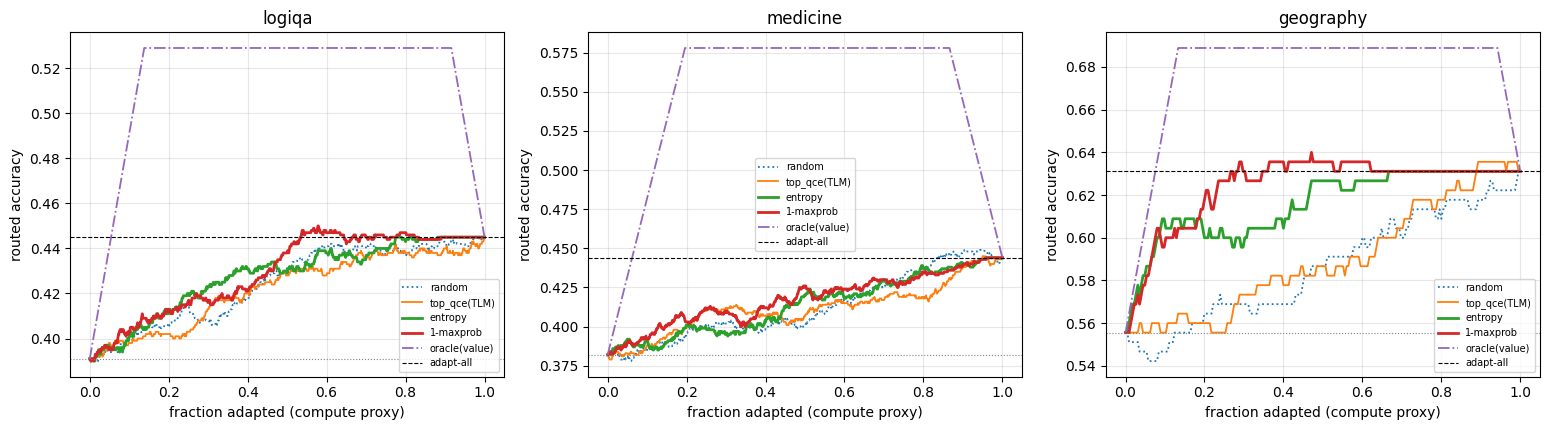

In [14]:
import matplotlib.pyplot as plt
fig, axes = plt.subplots(1, len(DATASETS), figsize=(5.2*len(DATASETS), 4.4), squeeze=False)
for ci, ds in enumerate(DATASETS):
    ax = axes[0][ci]; C = CURVES[ds]
    for name, (fr, accs) in C["curves"].items():
        ls = "-." if name.startswith("oracle") else (":" if name == "random" else "-")
        ax.plot(fr, accs, ls, label=name, lw=2 if name in ("entropy","1-maxprob") else 1.3)
    ax.axhline(C["adapt"], color="black", ls="--", lw=0.8, label="adapt-all")
    ax.axhline(C["base"], color="grey", ls=":", lw=0.8)
    ax.set_title(ds); ax.set_xlabel("fraction adapted (compute proxy)"); ax.set_ylabel("routed accuracy")
    ax.legend(fontsize=7); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

## How to read — the go/no-go

**GO** if a *deployable* signal (`entropy` / `1-maxprob` / `top_qce`) recovers 90% of the adaptation gain (`budget->90%gain`) at a **clearly lower** budget than `random`, and its curve sits above `top_qce`. That gap = full-TLM quality at a fraction of the adaptation cost — the compute-Pareto win, and the winnable framing (not accuracy).

- `peak_acc > adapt_all` for a deployable signal => the router also trims collateral (the base-tier avoiding harmful updates) — bonus, and the anti-forgetting angle.
- `oracle(value)` is the ceiling; the deployable-vs-oracle gap is how much a smarter router could still buy.
- If deployable signals **hug random**, S-BAR has no allocation signal on this bench -> yellow flag. Check whether it's a low-headroom bench (`oracle - base` small); the review expects separation on higher-headroom sets (medicine/gsm8k at larger scale), so don't kill it on a flat logiqa alone.

**Caveat:** this simulates *inference-time* routing from cached outcomes — a faithful proxy for selection quality, but the full compute claim (fewer training samples/tokens/steps) still needs GPU budget-arms. This test only decides whether those are worth training.